In [2]:
# read jsonl to pandas dataframe
import pandas as pd
import numpy as np
import torch
import shap
from transformers import AutoModelForSequenceClassification, AutoTokenizer

/Users/jeandelrosario/repos/NLP-final-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

def prepare_dataset_nli(texts, tokenizer, max_seq_length=None):
    max_seq_length = tokenizer.model_max_length if max_seq_length is None else max_seq_length
    premises = []
    hypotheses = []
    for text in texts:
        if "[MASK]" in text and len(set(text.split())) == 1:
            # If the input is fully masked, insert a separator
            premise, hypothesis = "[MASK]", "[MASK]"
            text = f"{premise} [SEP] {hypothesis}"
        elif " [SEP] " in text:
            premise, hypothesis = text.split(" [SEP] ")
        else:
            premise = text
            hypothesis = ""
        
        premises.append(premise)
        hypotheses.append(hypothesis)

    tokenized_examples = tokenizer(
        premises,
        hypotheses,
        truncation=True,
        max_length=max_seq_length,
        padding='max_length',
        return_tensors="pt"
    )


    # print("input_ids shape:", tokenized_examples["input_ids"].shape)
    # print("attention_mask shape:", tokenized_examples["attention_mask"].shape)

    # # Check specific tensor values to confirm padding (0s should appear for padding tokens)
    # print("input_ids:", tokenized_examples["input_ids"])
    # print("attention_mask:", tokenized_examples["attention_mask"])

    

    return tokenized_examples



# This function preprocesses an NLI dataset, tokenizing premises and hypotheses.
def prepare_dataset_nli_second_model(texts, tokenizer, max_seq_length=None):
    max_seq_length = tokenizer.model_max_length if max_seq_length is None else max_seq_length
    
    # for premise and hyphotesis, remove dots and commas
    texts = [p.replace('.', '').replace(',', '') for p in texts]
    premises = []
    hypotheses = []
    for text in texts:
        if "[MASK]" in text and len(set(text.split())) == 1:
            # If the input is fully masked, insert a separator
            premise, hypothesis = "[MASK]", "[MASK]"
            text = f"{premise} [SEP] {hypothesis}"
        elif " [SEP] " in text:
            premise, hypothesis = text.split(" [SEP] ")
        else:
            premise = text
            hypothesis = ""
        
        premises.append(premise)
        hypotheses.append(hypothesis)

    tokenized_examples = tokenizer(
        premises,
        hypotheses,
        truncation=True,
        max_length=max_seq_length,
        padding='max_length',
        return_tensors="pt"
    )

    return tokenized_examples

In [4]:
def print_prediction_metrics(path_to_jsonl):
    df = pd.read_json(path_to_jsonl, lines=True)

    # calculate global accuacy
    df['correct'] = np.where(df['label'] == df['predicted_label'], 1, 0)
    print('Global accuracy:', df['correct'].mean())
    
    # calculate accuracy for each class
    print('Accuracy by class:')
    print(df.groupby('label')['correct'].mean())


    # Calculate accuracy per genre
    print('Accuracy by genre:')
    print(df.groupby('genre')['correct'].agg(['count', 'mean']))


    # for slate genre, found accuracy per class
    slate_df = df[df['genre']=='slate']
    print('Accuracy by class for slate genre:')
    print(slate_df.groupby('label')['correct'].agg(['count', 'mean']))


    # for slate genre and 1 label, check the most common mistake
    slate_df_1 = slate_df[slate_df['label']==1]
    print('Accuracy by predicted_label for slate genre and 1 label:')
    print(slate_df_1.groupby('predicted_label')['correct'].agg(['count']) / slate_df_1['correct'].count())

In [5]:
print_prediction_metrics(path_to_jsonl='eval_output/eval_predictions.jsonl')

Global accuracy: 0.8066225165562914
Accuracy by class:
label
0    0.826387
1    0.767851
2    0.822907
Name: correct, dtype: float64
Accuracy by genre:
            count      mean
genre                      
fiction      1973  0.805879
government   1945  0.845244
slate        1955  0.753964
telephone    1966  0.815361
travel       1976  0.812753
Accuracy by class for slate genre:
       count      mean
label                 
0        683  0.784773
1        651  0.711214
2        621  0.764895
Accuracy by predicted_label for slate genre and 1 label:
                    count
predicted_label          
0                0.122888
1                0.711214
2                0.165899


In [6]:
print_prediction_metrics(path_to_jsonl='eval_trained_model_aug/eval_predictions.jsonl')

Global accuracy: 0.8015282730514519
Accuracy by class:
label
0    0.824375
1    0.761127
2    0.816060
Name: correct, dtype: float64
Accuracy by genre:
            count      mean
genre                      
fiction      1973  0.796249
government   1945  0.842674
slate        1955  0.763171
telephone    1966  0.795015
travel       1976  0.810729
Accuracy by class for slate genre:
       count      mean
label                 
0        683  0.795022
1        651  0.723502
2        621  0.769726
Accuracy by predicted_label for slate genre and 1 label:
                    count
predicted_label          
0                0.116743
1                0.723502
2                0.159754


In [7]:
print_prediction_metrics(path_to_jsonl='eval_fine_tune_slate_aug/eval_predictions.jsonl')

Global accuracy: 0.804381049414162
Accuracy by class:
label
0    0.829261
1    0.750240
2    0.830065
Name: correct, dtype: float64
Accuracy by genre:
            count      mean
genre                      
fiction      1973  0.801825
government   1945  0.846787
slate        1955  0.757545
telephone    1966  0.812309
travel       1976  0.803644
Accuracy by class for slate genre:
       count      mean
label                 
0        683  0.793558
1        651  0.703533
2        621  0.774557
Accuracy by predicted_label for slate genre and 1 label:
                    count
predicted_label          
0                0.129032
1                0.703533
2                0.167435


In [8]:
print_prediction_metrics(path_to_jsonl='eval_fine_tune_slate/eval_predictions.jsonl')

Global accuracy: 0.8050942435048395
Accuracy by class:
label
0    0.821213
1    0.761127
2    0.830377
Name: correct, dtype: float64
Accuracy by genre:
            count      mean
genre                      
fiction      1973  0.798277
government   1945  0.850386
slate        1955  0.758568
telephone    1966  0.815870
travel       1976  0.802632
Accuracy by class for slate genre:
       count      mean
label                 
0        683  0.793558
1        651  0.703533
2        621  0.777778
Accuracy by predicted_label for slate genre and 1 label:
                    count
predicted_label          
0                0.129032
1                0.703533
2                0.167435


In [9]:
print_prediction_metrics(path_to_jsonl='eval_output_2/eval_predictions.jsonl')

Global accuracy: 0.7943963321446765
Accuracy by class:
label
0    0.774073
1    0.788985
2    0.821662
Name: correct, dtype: float64
Accuracy by genre:
            count      mean
genre                      
fiction      1973  0.795743
government   1945  0.832905
slate        1955  0.745780
telephone    1966  0.802645
travel       1976  0.795040
Accuracy by class for slate genre:
       count      mean
label                 
0        683  0.721816
1        651  0.740399
2        621  0.777778
Accuracy by predicted_label for slate genre and 1 label:
                    count
predicted_label          
0                0.084485
1                0.740399
2                0.175115


In [10]:



# Load the JSONL file
df = pd.read_json('eval_output/eval_predictions.jsonl', lines=True)
df_second_model = pd.read_json('eval_fine_tune_slate/eval_predictions.jsonl', lines=True)

# calculate global accuacy
df['correct'] = np.where(df['label'] == df['predicted_label'], 1, 0)
print('Global accuracy:', df['correct'].mean())
# calculate global accuacy second model
df_second_model['correct'] = np.where(df_second_model['label'] == df_second_model['predicted_label'], 1, 0)
print('Global accuracy second model:', df_second_model['correct'].mean())

# calculate accuracy for each class
print('Accuracy by class:')
print(df.groupby('label')['correct'].mean())
# calculate accuracy for each class second model
print('Accuracy by class second model:')
print(df_second_model.groupby('label')['correct'].mean())

# Calculate accuracy per genre
print('Accuracy by genre:')
print(df.groupby('genre')['correct'].agg(['count', 'mean']))
# Calculate accuracy per genre second model
print('Accuracy by genre second model:')
print(df_second_model.groupby('genre')['correct'].agg(['count', 'mean']))

# for slate genre, found accuracy per class
slate_df = df[df['genre']=='slate']
print('Accuracy by class for slate genre:')
print(slate_df.groupby('label')['correct'].agg(['count', 'mean']))
# for slate genre, found accuracy per class second model
slate_df_second_model = df_second_model[df_second_model['genre']=='slate']
print('Accuracy by class for slate genre second model:')
print(slate_df_second_model.groupby('label')['correct'].agg(['count', 'mean']))

# for slate genre and 1 label, check the most common mistake
slate_df_1 = slate_df[slate_df['label']==1]
print('Accuracy by predicted_label for slate genre and 1 label:')
print(slate_df_1.groupby('predicted_label')['correct'].agg(['count']) / slate_df_1['correct'].count())

# for slate genre and 1 label, check the most common mistake second model
slate_df_1_second_model = slate_df_second_model[slate_df_second_model['label']==1]
print('Accuracy by predicted_label forslate genre and 1 label second model:')
print(slate_df_1_second_model.groupby('predicted_label')['correct'].agg(['count']) / slate_df_1_second_model['correct'].count())

Global accuracy: 0.8066225165562914
Global accuracy second model: 0.8050942435048395
Accuracy by class:
label
0    0.826387
1    0.767851
2    0.822907
Name: correct, dtype: float64
Accuracy by class second model:
label
0    0.821213
1    0.761127
2    0.830377
Name: correct, dtype: float64
Accuracy by genre:
            count      mean
genre                      
fiction      1973  0.805879
government   1945  0.845244
slate        1955  0.753964
telephone    1966  0.815361
travel       1976  0.812753
Accuracy by genre second model:
            count      mean
genre                      
fiction      1973  0.798277
government   1945  0.850386
slate        1955  0.758568
telephone    1966  0.815870
travel       1976  0.802632
Accuracy by class for slate genre:
       count      mean
label                 
0        683  0.784773
1        651  0.711214
2        621  0.764895
Accuracy by class for slate genre second model:
       count      mean
label                 
0        683  0.79355

In [80]:

# analyze shap values for slate genre
slate_df = df[df['genre']=='slate']
slate_texts = slate_df.apply(lambda row: f"{row['premise']} [SEP] {row['hypothesis']}", axis=1).tolist()

# analzye shap values for slate genre second model
slate_df_second_model = df_second_model[df_second_model['genre']=='slate']
slate_texts_second_model = slate_df_second_model.apply(lambda row: f"{row['premise'].replace(',', '').replace('.', '')} [SEP] {row['hypothesis'].replace(',', '').replace('.', '')}", axis=1).tolist()

# Load your model and tokenizer
print("loading model and tokenizer...")
model = AutoModelForSequenceClassification.from_pretrained("./trained_model")
tokenizer = AutoTokenizer.from_pretrained("./trained_model")
model.eval()
print("done")
# Load second model and tokenizer
print("loading model and tokenizer...")
model2 = AutoModelForSequenceClassification.from_pretrained("./trained_model_2")
tokenizer2 = AutoTokenizer.from_pretrained("./trained_model_2")
model2.eval()
print("done")

def predict(texts):
    inputs = prepare_dataset_nli(texts, tokenizer, max_seq_length=128 # TODO: max length is hardcoded for now
                                            )
    
    outputs= model(**inputs)
    return torch.softmax(outputs.logits, dim=-1).detach().numpy()


def predict_second_model(texts):
    inputs = prepare_dataset_nli_second_model(texts, tokenizer2, max_seq_length=128 # TODO: max length is hardcoded for now
                                            )
    
    outputs= model2(**inputs)
    return torch.softmax(outputs.logits, dim=-1).detach().numpy()



# explainer = shap.Explainer(predict, tokenizer)
# shap_values = explainer(slate_texts[:50])  # Adjust sample size as needed

explainer_second_model = shap.Explainer(predict_second_model, tokenizer2)
shap_values_second_model = explainer_second_model(slate_texts_second_model[:50])  # Adjust sample size as needed

# print("shap_values shape:", shap_values.shape)
# print("shap_values.values shape:", shap_values.values.shape)

# for i, sv in enumerate(shap_values):
#     print(f"Shape of shap_values[{i}]:", sv.values.shape)
#     print("shap_values entry:", sv.values)


# if len(shap_values.values.shape) == 1:
#     shap_values.values = shap_values.values.reshape(1, -1)


# shap.summary_plot(shap_values, slate_texts[:2])


loading model and tokenizer...
done
loading model and tokenizer...
done


PartitionExplainer explainer: 51it [03:14,  4.05s/it]                        


In [37]:
for ix, row in slate_df[slate_df['correct'] == False][['premise', 'hypothesis', 'label', 'predicted_label']].sample(n=10, random_state=42).iterrows():
    print('ratio: ', len(row[0]) / len(row[1]))
    print('premise: ')
    print(row[0], len(row[0].split(' ')))
    print('hypothesis: ')
    print(row[1], len(row[1].split(' ')))
    print('label: ')
    print(row[2])
    print('predicted label: ')
    print(row[3])

ratio:  3.7045454545454546
premise: 
I think it behooves Slate, in its effort to take over the public-opinion industry, to make a thorough effort to uncover the truth behind this unnatural connection. 27
hypothesis: 
Slate is obliged to launch an investigation. 7
label: 
1
predicted label: 
0
ratio:  4.861111111111111
premise: 
The movie isn't clear on where the secret report that kicked off Bergman's interest in tobacco came from, or who in the FDA thought it was a good idea to turn him onto Wigand. 34
hypothesis: 
Bergman does not know who Wigand is. 7
label: 
2
predicted label: 
0
ratio:  2.274193548387097
premise: 
Stale macho jokes and formulaic cliffhangers drive this chase-by-numbers thriller on the bumpy road to nowhere (Holden, the New York Times ). 22
hypothesis: 
Stridently macho, loud and predictable, the film goes nowhere. 9
label: 
0
predicted label: 
2
ratio:  1.4368932038834952
premise: 
As for the divisive issue of whether the Mass is a sacrifice for the remission of s

/var/folders/jl/7zyjc6xd1rzbt2v2zsg2fdp00000gn/T/ipykernel_2433/3943381669.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('ratio: ', len(row[0]) / len(row[1]))
/var/folders/jl/7zyjc6xd1rzbt2v2zsg2fdp00000gn/T/ipykernel_2433/3943381669.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(row[0], len(row[0].split(' ')))
/var/folders/jl/7zyjc6xd1rzbt2v2zsg2fdp00000gn/T/ipykernel_2433/3943381669.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posit

In [152]:
slate_df['hypothesis_length'] = slate_df['hypothesis'].apply(lambda x: len(x))
slate_df.groupby('correct')['hypothesis_length'].median()

/var/folders/jl/7zyjc6xd1rzbt2v2zsg2fdp00000gn/T/ipykernel_35553/3417959204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slate_df['hypothesis_length'] = slate_df['hypothesis'].apply(lambda x: len(x))


correct
0    54.0
1    55.0
Name: hypothesis_length, dtype: float64

In [12]:
df['hypothesis_length'] = df['hypothesis'].apply(lambda x: len(x))
df['premise_length'] = df['premise'].apply(lambda x: len(x))
df['hypo_to_premise_length_ratio'] = df['hypothesis_length'] / df['premise_length']
df['premise_to_hypo_length_ratio'] = df['premise_length'] / df['hypothesis_length']

df.groupby(['genre', 'correct'])[['hypothesis_length', 'premise_length', 'hypo_to_premise_length_ratio', 'premise_to_hypo_length_ratio']].mean()

hypothesis_length  premise_length  \
genre      correct                                      
fiction    0                45.626632       66.968668   
           1                44.297484       60.826415   
government 0                65.299003      141.431894   
           1                67.012165      137.242701   
slate      0                56.553015      120.530146   
           1                58.535957      111.111262   
telephone  0                50.787879      132.669421   
           1                48.781036      109.460387   
travel     0                60.475676      128.729730   
           1                61.853674      127.140722   

                    hypo_to_premise_length_ratio  premise_to_hypo_length_ratio  
genre      correct                                                              
fiction    0                            0.913874                      1.531709  
           1                            0.959696                      1.437011  
government 0                            0.626558                      2.275056  
           1                            0.621059                      2.197383  
slate      0                            0.641281                      2.329000  
           1                            0.734886                      2.020716  
telephone  0                            0.610590                      2.747171  
           1                            0.686413                      2.303601  
travel     0                            0.614010                      2.285138  
           1                            0.622904                      2.205971

In [116]:
shap.plots.force(explainer.expected_value[0], shap_values[0].values, tokenized_text)
shap.plots.text(shap_values[7])

TypeError: 'NoneType' object is not subscriptable

In [15]:
slate_df.reset_index().loc[:20, ["label", "predicted_label"]]

,label,predicted_label
0,1,1
1,2,2
2,1,1
3,1,1
4,0,1
5,0,0
6,2,0
7,0,1
8,0,1
9,0,0


In [ ]:
# get shap values of rows when the label is 1 but predicted something else
slate_df_1_mistakes = slate_df[(slate_df['label']==1) & (slate_df['predicted_label']!=1)]
slate_texts_1_mistakes = slate_df_1_mistakes.apply(lambda row: f"{row['premise']} [SEP] {row['hypothesis']}", axis=1).tolist()

Shap plot for class label 0
------Base model


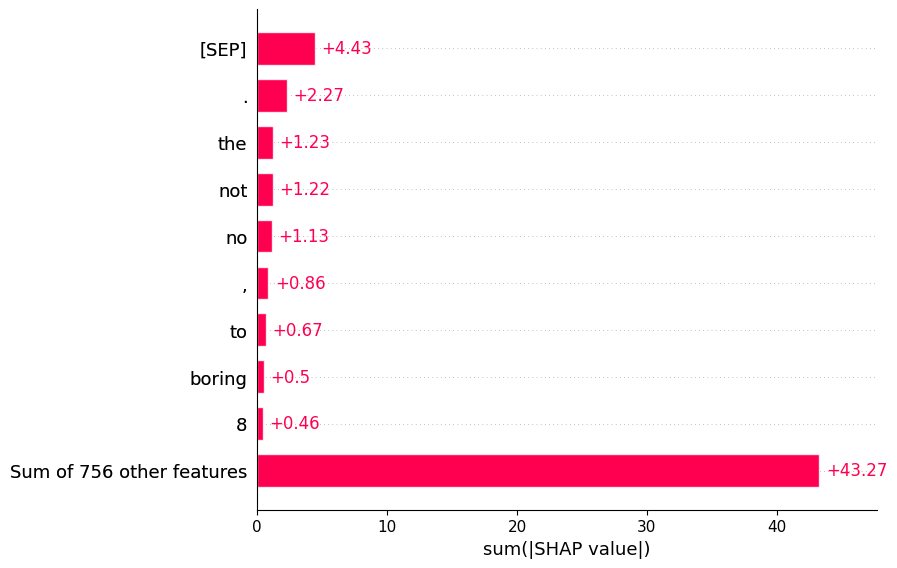

------Second model


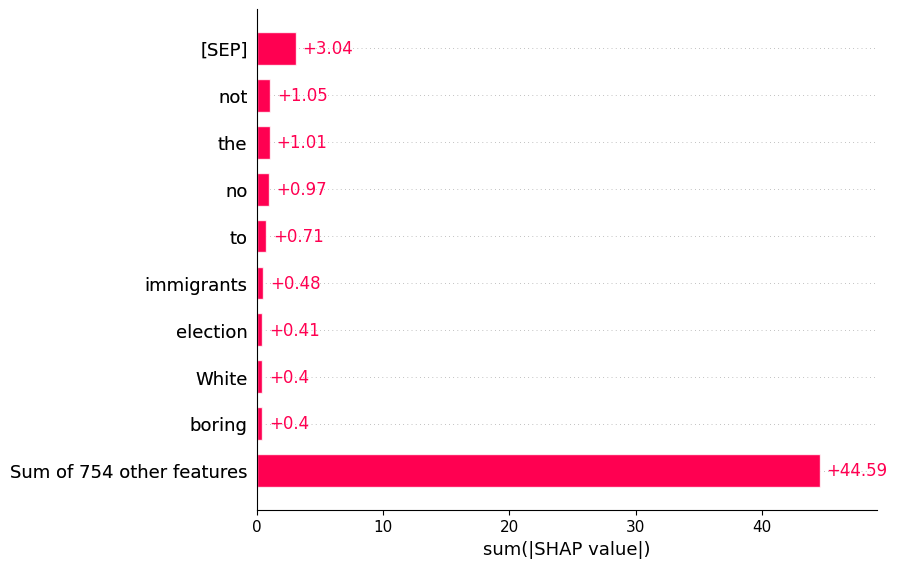

Shap plot for class label 1
------Base model


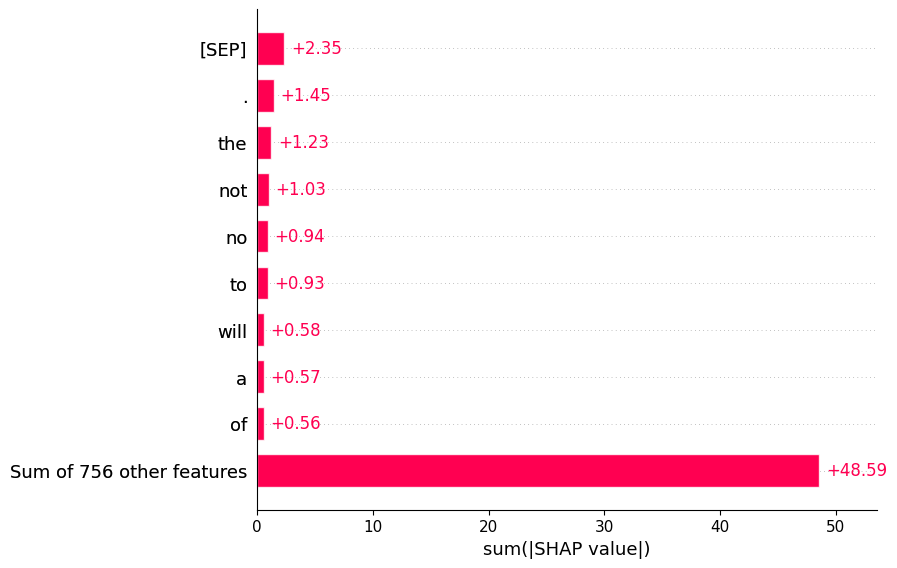

------Second model


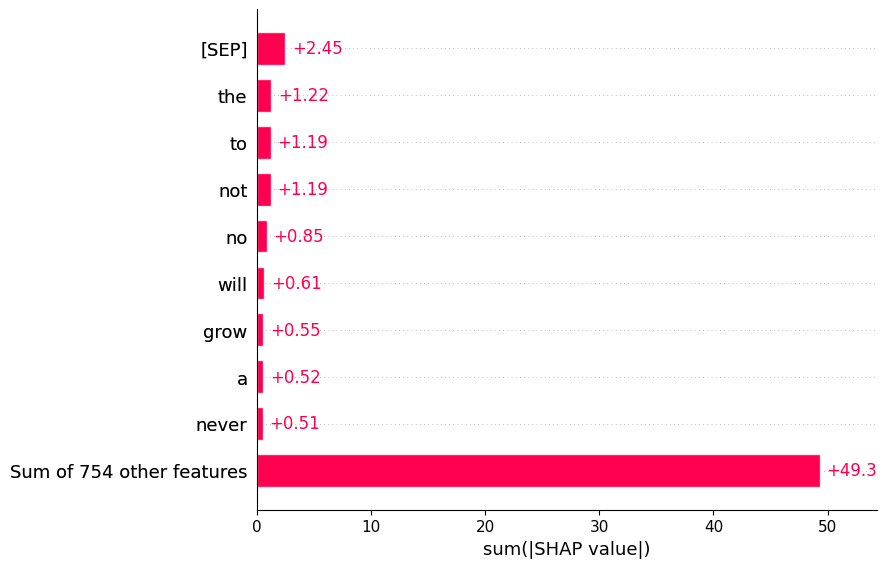

Shap plot for class label 2
------Base model


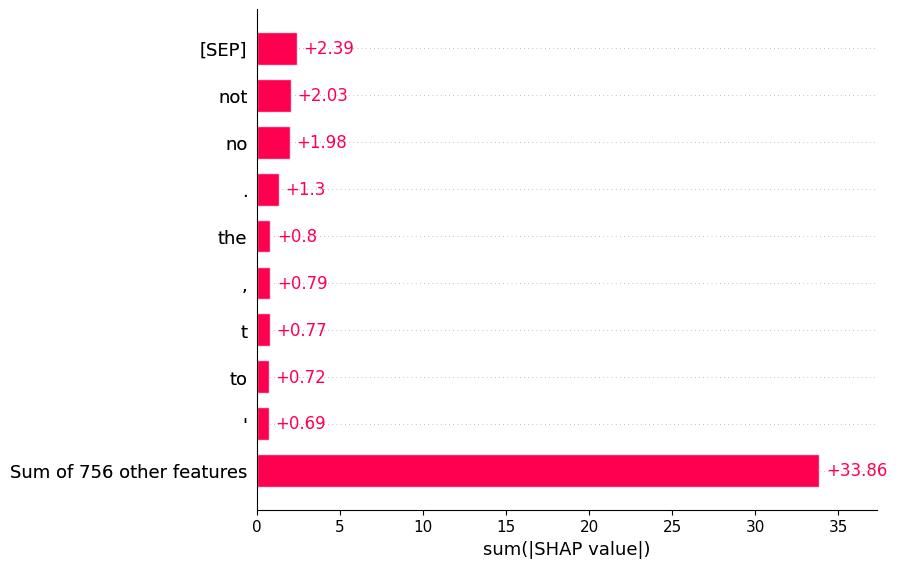

------Second model


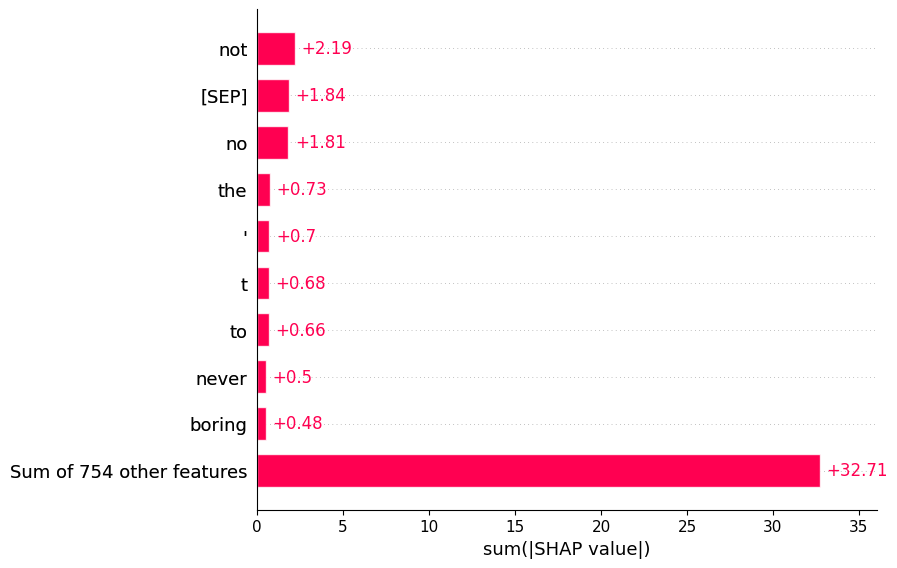

In [81]:
print('Shap plot for class label 0')
print('------Base model')
shap.plots.bar(shap_values.abs[:,:,0].sum(0))
print('------Second model')
shap.plots.bar(shap_values_second_model.abs[:,:,0].sum(0))
print('Shap plot for class label 1')
print('------Base model')
shap.plots.bar(shap_values.abs[:,:,1].sum(0))
print('------Second model')
shap.plots.bar(shap_values_second_model.abs[:,:,1].sum(0))
print('Shap plot for class label 2')
print('------Base model')
shap.plots.bar(shap_values.abs[:,:,2].sum(0))
print('------Second model')
shap.plots.bar(shap_values_second_model.abs[:,:,2].sum(0))

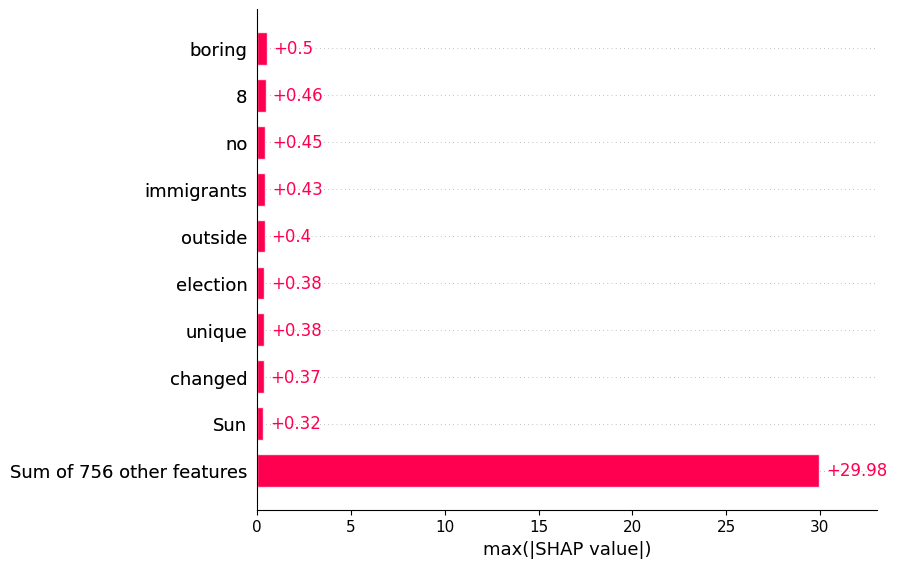

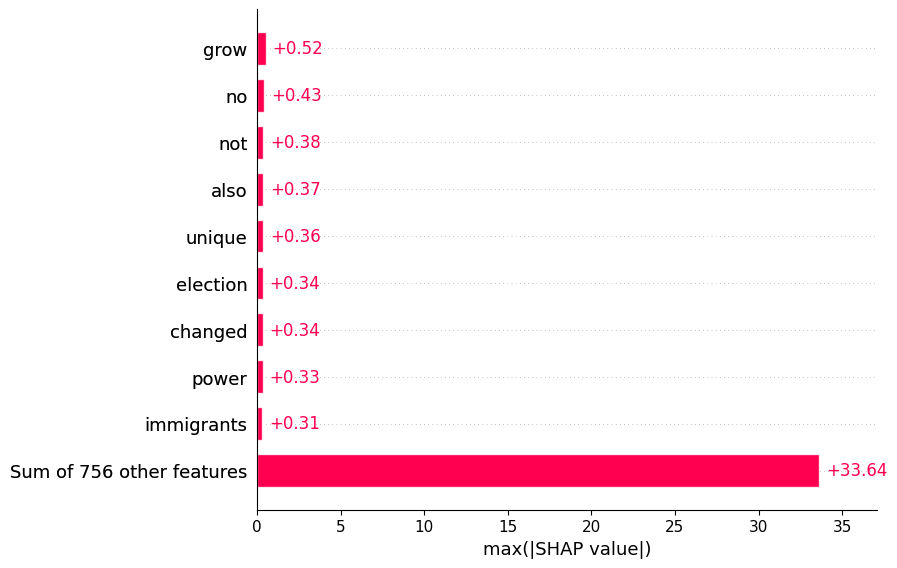

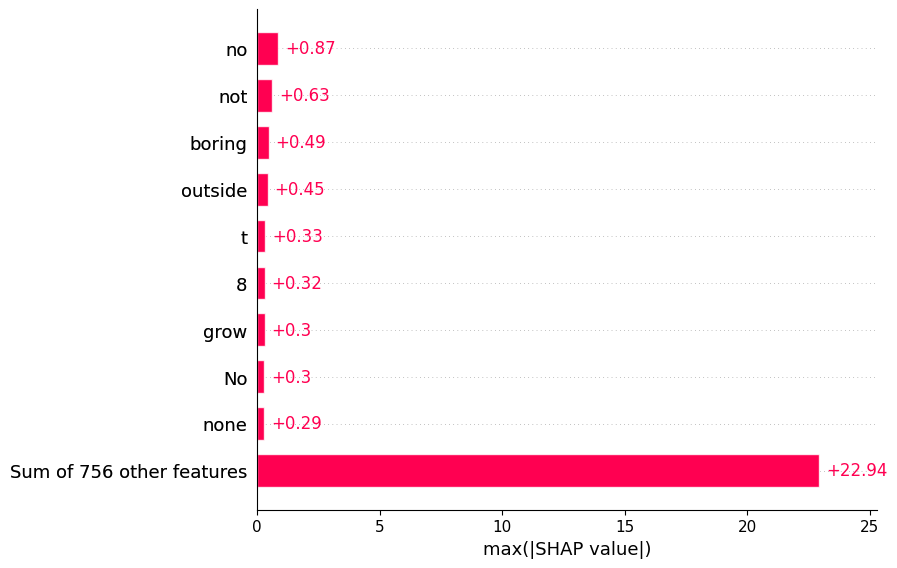

In [82]:
shap.plots.bar(shap_values.abs[:,:,0].max(0))

shap.plots.bar(shap_values.abs[:,:,1].max(0))

shap.plots.bar(shap_values.abs[:,:,2].max(0))

In [26]:
shap_values.abs.shape

(100, None, 3)

In [28]:
shap_values.abs[:,:,0].sum(0)

.values =
array([0.25845786, 0.4242713 , 0.63110939, ..., 0.12983498, 0.10217952,
       0.13317967])

.base_values =
np.float64(0.6495418548583984)

In [ ]:
slate_df_1 = slate_df[slate_df['label'] == 1].copy()


In [85]:
from deep_translator import GoogleTranslator

def backtranslate(text, source_lang="en", target_lang="fr"):
    try:
        # Translate from English to target language (e.g., French)
        translated = GoogleTranslator(source=source_lang, target=target_lang).translate(text)
        # Translate back to English
        back_translated = GoogleTranslator(source=target_lang, target=source_lang).translate(translated)
        return back_translated
    except Exception as e:
        print(f"Error in backtranslation: {e}")
        return text  # Return original text in case of an error

# Example usage
sample_text = "The quick brownish fox jumps over the lazy dog."
augmented_text = backtranslate(sample_text)
print("Original:", sample_text)
print("Backtranslated:", augmented_text)


Original: The quick brownish fox jumps over the lazy dog.
Backtranslated: The quick brown fox jumps over the lazy dog.


In [86]:
import nltk
from nltk.corpus import wordnet
import random

nltk.download("wordnet")
nltk.download("omw-1.4")

def synonym_replacement(sentence, num_replacements=1):
    words = sentence.split()
    for _ in range(num_replacements):
        # Choose a random word to replace
        word_to_replace = random.choice(words)
        synonyms = wordnet.synsets(word_to_replace)
        if synonyms:
            # Get a list of synonyms
            synonym_list = set([lemma.name() for syn in synonyms for lemma in syn.lemmas() if lemma.name() != word_to_replace])
            if synonym_list:
                # Replace the word with a random synonym
                replacement = random.choice(list(synonym_list))
                words = [replacement if word == word_to_replace else word for word in words]
    return " ".join(words)

# Example usage
sentence = "The quick brown fox jumps over the lazy dog."
augmented_sentence = synonym_replacement(sentence, num_replacements=2)
print("Original:", sentence)
print("Synonym replaced:", augmented_sentence)


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jeandelrosario/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/jeandelrosario/nltk_data...


Original: The quick brown fox jumps over the lazy dog.
Synonym replaced: The quick brownness fox alternate over the lazy dog.


In [17]:
import time
from transformers import pipeline

# Load summarization pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn", device='mps')


In [35]:

# Example premise
premise = "The movie isn't clear on where the secret report that kicked off Bergman's interest in tobacco came from, or who in the FDA thought it was a good idea to turn him onto Wigand."

# Measure time
start_time = time.time()
summary = summarizer(premise, max_length=int(len(premise) / 4.17), min_length=int(len(premise) / 16), do_sample=False)[0]['summary_text']
end_time = time.time()
print(f"Original Text: {premise}")
print(f"Summary: {summary}")
print(f"Time Taken: {end_time - start_time:.2f} seconds")

Original Text: The movie isn't clear on where the secret report that kicked off Bergman's interest in tobacco came from, or who in the FDA thought it was a good idea to turn him onto Wigand.
Summary: The movie isn't clear on where the secret report that kicked off Bergman's interest in tobacco came from, or who in the FDA thought it was a good idea.
Time Taken: 1.19 seconds


In [30]:
print(len(summary))

119


In [31]:
print(len(premise))

178


In [22]:
from transformers import AutoTokenizer

# Load BART tokenizer
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")
# Example dataset
premises = slate_df['premise'].tolist()

# Compute lengths
length_stats = []
for premise in premises:
    char_length = len(premise)
    token_length = len(tokenizer(premise)['input_ids'])  # Token count
    length_stats.append({'char_length': char_length, 'token_length': token_length})

# Convert to DataFrame for analysis
import pandas as pd
length_df = pd.DataFrame(length_stats)

# Calculate the average ratio
length_df['char_to_token_ratio'] = length_df['char_length'] / length_df['token_length']
average_ratio = length_df['char_to_token_ratio'].mean()
print(f"Average Characters per Token: {average_ratio:.2f}")

def char_to_token_estimate(char_length, avg_ratio=average_ratio):
    return int(char_length / avg_ratio)

# Example: Convert a string length of 200 characters to tokens
estimated_tokens = char_to_token_estimate(200)
print(f"Estimated Tokens: {estimated_tokens}")


Average Characters per Token: 4.17
Estimated Tokens: 47


In [ ]:
slate_df['hypo']